## SecureBERT–BiLSTM–Attention Hybrid Architecture


In [1]:
from pathlib import Path
import os
PROJECT_ROOT=Path.cwd()
DATA_DIR=PROJECT_ROOT/'data'
OUTPUT_DIR=PROJECT_ROOT/'outputs'
DEPLOYMENT_DIR=PROJECT_ROOT/'deployment'
for d in [DATA_DIR,OUTPUT_DIR,DEPLOYMENT_DIR]: d.mkdir(exist_ok=True)
output_dir='outputs'

### 0. Setup & Upload

### Imports

In [2]:
import re
import ast
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib # Added for saving/loading scikit-learn models and data

sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)

In [4]:
#  !pip install -q wordcloud


In [3]:
# from google.colab import files
file_path = str(DATA_DIR/'NEW_DATASET_updated.csv')
df = pd.read_csv(file_path)
print("Loaded:", file_path, "Shape:", df.shape)


Loaded: d:\ROHITH PROJECT\SAI_KIRAN\FINAL\data\NEW_DATASET_updated.csv Shape: (1420, 17)


In [6]:
MODELS_DIR = "models_outputs"
os.makedirs(MODELS_DIR, exist_ok=True)
FORCE_RETRAIN = False # Set to True to force retraining even if saved models exist

print(f"Models will be saved to/loaded from: {MODELS_DIR}")
print(f"FORCE_RETRAIN is set to: {FORCE_RETRAIN}")

Models will be saved to/loaded from: models_outputs
FORCE_RETRAIN is set to: False


### 1. Load & Inspect

In [7]:
df.head()

,id,text,relations,diagnosis,solutions,id_1,label_1,start_offset_1,end_offset_1,id_2,label_2,start_offset_2,end_offset_2,id_3,label_3,start_offset_3,end_offset_3
0,249,A cybersquatting domain save-russia[.]today is...,"[{'from_id': 44658, 'id': 9, 'to_id': 44659, '...",The diagnosis is a cyber attack that involves ...,1. Implementing DNS filtering to block access ...,44656,ATTACK-PATTERN,2,16,44657.0,URL,24.0,43.0,44658.0,ATTACK-PATTERN,57.0,68.0
1,14309,"Like the Android Maikspy, it first sends a not...","[{'from_id': 48531, 'id': 445, 'to_id': 48532,...",The diagnosis is that the entity identified as...,1. Implementing a robust anti-malware software...,48530,SOFTWARE,9,17,48531.0,MALWARE,17.0,24.0,48532.0,INFRASTUCTURE,63.0,73.0
2,13996,While analyzing the technical details of this ...,"[{'from_id': 48781, 'id': 461, 'to_id': 48782,...",Diagnosis: APT37/Reaper/Group 123 is responsib...,1. Implementing advanced threat detection tech...,48781,THREAT-ACTOR,188,194,48782.0,THREAT-ACTOR,210.0,217.0,48783.0,THREAT-ACTOR,220.0,229.0
3,13600,(Note that Flash has been declared end-of-life...,"[{'from_id': 51688, 'id': 1133, 'to_id': 51689...",The diagnosis is a malware infection. The enti...,1. Implementing a robust antivirus software th...,51687,TIME,62,79,51688.0,MALWARE,207.0,215.0,51689.0,MALWARE,247.0,258.0
4,14364,Figure 21. Connection of Maikspy variants to 1...,"[{'from_id': 51780, 'id': 1161, 'to_id': 44372...",The diagnosis is that Maikspy malware variants...,1. Implementing a robust firewall system that ...,51779,URL,163,191,51777.0,URL,70.0,93.0,51781.0,MALWARE,120.0,127.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1420 entries, 0 to 1419
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              1420 non-null   int64  
 1   text            1420 non-null   str    
 2   relations       1420 non-null   str    
 3   diagnosis       1419 non-null   str    
 4   solutions       1420 non-null   str    
 5   id_1            1420 non-null   int64  
 6   label_1         1420 non-null   str    
 7   start_offset_1  1420 non-null   int64  
 8   end_offset_1    1420 non-null   int64  
 9   id_2            1354 non-null   float64
 10  label_2         1354 non-null   str    
 11  start_offset_2  1354 non-null   float64
 12  end_offset_2    1354 non-null   float64
 13  id_3            910 non-null    float64
 14  label_3         910 non-null    str    
 15  start_offset_3  910 non-null    float64
 16  end_offset_3    910 non-null    float64
dtypes: float64(6), int64(4), str(7)
memory usage

In [9]:
df.describe()

,id,id_1,start_offset_1,end_offset_1,id_2,start_offset_2,end_offset_2,id_3,start_offset_3,end_offset_3
count,1420.000000,1420.000000,1420.000000,1420.000000,1354.000000,1354.000000,1354.000000,910.000000,910.000000,910.000000
mean,68358.646479,612930.023944,38.640845,55.576761,599728.495569,72.194239,89.380355,591664.526374,105.602198,121.578022
std,45304.230638,406350.094711,43.590839,44.812086,409748.033207,45.334577,47.982529,411289.282926,57.738514,59.439794
min,105.000000,377.000000,0.000000,4.000000,771.000000,0.000000,4.000000,976.000000,0.000000,5.000000
25%,4817.750000,50077.250000,13.000000,28.000000,49696.750000,46.000000,60.000000,49718.000000,74.000000,91.000000
50%,100233.500000,900673.500000,28.000000,44.000000,900584.500000,65.000000,83.000000,900396.500000,107.000000,120.000000
75%,100588.250000,901707.750000,52.000000,72.000000,901570.250000,91.000000,110.000000,901126.250000,128.000000,144.000000
max,100943.000000,902401.000000,428.000000,451.000000,902402.000000,471.000000,535.000000,902392.000000,601.000000,665.000000


### 2. Data Cleaning & Preprocessing

#### 2.1 Missing Value Analysis

In [10]:
print(df.isna().sum())

id                  0
text                0
relations           0
diagnosis           1
solutions           0
id_1                0
label_1             0
start_offset_1      0
end_offset_1        0
id_2               66
label_2            66
start_offset_2     66
end_offset_2       66
id_3              510
label_3           510
start_offset_3    510
end_offset_3      510
dtype: int64


#### 2.2 Handle Missing Values

In [11]:

for slot in [2, 3]:
    for col in [f'id_{slot}', f'start_offset_{slot}', f'end_offset_{slot}']:
        df[col] = df[col].fillna(-1)
    df[f'label_{slot}'] = df[f'label_{slot}'].fillna('NONE')

print("Missing values after handling:")
print(df[['id_2', 'label_2', 'start_offset_2', 'end_offset_2',
          'id_3', 'label_3', 'start_offset_3', 'end_offset_3']].isna().sum())


Missing values after handling:
id_2              0
label_2           0
start_offset_2    0
end_offset_2      0
id_3              0
label_3           0
start_offset_3    0
end_offset_3      0
dtype: int64


In [12]:
feature_stats = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Missing Values': df.isnull().sum().values,
    'Duplicate Values (within feature)': [df[col].duplicated().sum() for col in df.columns]
})
display(feature_stats)

,Feature,Data Type,Missing Values,Duplicate Values (within feature)
0,id,int64,0,72
1,text,str,0,178
2,relations,str,0,137
3,diagnosis,str,1,622
4,solutions,str,0,979
5,id_1,int64,0,72
6,label_1,str,0,1403
7,start_offset_1,int64,0,1261
8,end_offset_1,int64,0,1247
9,id_2,float64,0,137


#### 2.3 Duplicate Detection & Removal

In [13]:
dupe_ids = df['id'].duplicated().sum()
print(f"Duplicate top-level ids: {dupe_ids}")
# not removed here since 'id' is not guaranteed to be a unique key
# in the source data, and rows are otherwise distinct records.


Duplicate top-level ids: 72


#### 2.4 Data Type Validation & Conversion

In [14]:
for col in ['id_1', 'id_2', 'id_3']:
    df[col] = df[col].astype(int)
for col in ['text', 'diagnosis', 'solutions']:
    df[col] = df[col].astype(str)
print(df.dtypes[['id_1', 'id_2', 'id_3', 'text', 'diagnosis', 'solutions']])


id_1         int64
id_2         int64
id_3         int64
text           str
diagnosis      str
solutions      str
dtype: object


#### 2.5 Text Cleaning & Normalization

In [15]:
def clean_text(text):
    if pd.isna(text) or text == '':
        return text
    text = re.sub(r'\s+', ' ', text)   # collapse repeated whitespace
    text = text.strip()
    return text

df['text'] = df['text'].apply(clean_text)
df['diagnosis'] = df['diagnosis'].apply(clean_text)
df['solutions'] = df['solutions'].apply(clean_text)

print("Text cleaned and normalized")
print("\nSample cleaned text:")
print(df['text'].iloc[0][:150] + "...")


Text cleaned and normalized

Sample cleaned text:
A cybersquatting domain save-russia[.]today is launching DoS attacks on Ukrainian news sites....


#### 2.6 Label Standardization

In [ ]:
for col in ['label_1', 'label_2', 'label_3']:
    df[col] = df[col].astype(str).str.strip()


#### 2.7 Entity Label Case Normalization

In [17]:
# 'url' and 'URL' were recorded inconsistently in the raw data as two different types; normalize case so they're treated as one.
for col in ['label_1', 'label_2', 'label_3']:
    df[col] = df[col].str.upper().replace('NAN', np.nan)

print("Unique entity labels after normalization:")
all_labels = pd.concat([df['label_1'], df['label_2'], df['label_3']])
print(sorted(all_labels[all_labels != 'NONE'].dropna().unique()))


Unique entity labels after normalization:
['ATTACK-PATTERN', 'CAMPAIGN', 'EMAIL', 'FILEPATH', 'HASH', 'IDENTITY', 'INFRASTRUCTURE', 'INFRASTUCTURE', 'IPV4', 'LOCATION', 'MALWARE', 'REGISTRYKEY', 'SOFTWARE', 'THREAT-ACTOR', 'TIME', 'TOOLS', 'URL', 'VULNERABILITY']


### 3. Label Construction — Threat Category

The dataset does not contain a native document-level category column
(`diagnosis` is free text; `label_1/2/3` are NER-style entity tags, not a
record-level topic). A threat category is constructed via keyword-rule
matching over the record's own text, checked in priority order (most specific
pattern first), so the label is derivable from exactly the information the
model receives as input.


In [18]:
def categorize(t: str) -> str:
    MALWARE_FAMILIES = ['maikspy', 'virlock', 'protux', 'vpnfilter', 'pclock', 'emotet',
        'trickbot', 'agenttesla', 'redline', 'qakbot', 'icedid', 'asyncrat', 'nanocore',
        'formbook', 'lokibot', 'dridex', 'bazarloader', 'gootkit', 'njrat', 'plugx',
        'smokeloader', 'raccoon stealer', 'vidar', 'strelastealer', 'xworm', 'capesand', 'mimikatz']
    RANSOMWARE_FAMILIES = ['lockbit', 'conti', 'revil', 'blackcat', 'hive', 'ryuk', 'maze',
        'darkside', 'cl0p', 'blackbyte', 'royal', 'akira', 'play', 'rhysida', 'medusa', 'babuk']
    APT_ACTOR_NAMES = ['charming kitten', 'carbanak', 'fin7', 'lazarus', 'turla', 'kimsuky',
        'muddywater', 'wizard spider', 'winnti', 'volt typhoon', 'scattered spider',
        'sandworm', 'lapsus\\$', 'urpage', 'x4k']

    if re.search(r'ddos|denial of service|\bdos attack|flood(ed|ing)? (the|.*?)traffic|overwhelm', t):
        return 'DoS/DDoS Attack'
    if re.search(r'ransomware|ransom note|encrypt(ed|ing|s)? (the |their |its )?(files|systems|data)|demand(ed|ing)? (a |)?(ransom|payment)', t) or any(f in t for f in RANSOMWARE_FAMILIES):
        return 'Ransomware'
    if re.search(r'phish|malicious (email|document|link|attachment)|vba macro|social engineering|spoof|credential.harvest|fake login', t):
        return 'Phishing / Social Engineering'
    if re.search(r'\bcve-\d|vulnerab|remote code execution|\brce\b|exploited in the wild|zero-day|patch(ed|ing)?|unpatched|flaw in', t):
        return 'Vulnerability Exploitation'
    if re.search(r'espionage|apt\d|state-sponsored|nation-state|cyber espionage|intelligence.gathering|surveillance operation', t):
        return 'Espionage / APT Campaign'
    if re.search(r'data leak|data breach|leakage|exfiltrat|compromised email addresses|exposed (records|data|database)|unsecured (data|database|bucket)|unauthorized access', t):
        return 'Data Breach / Leakage'
    if re.search(r'malware|trojan|backdoor|infect(ed|ion)|spyware|\brat\b|c&c|c2\b|payload|dropped a|loader|downloader|keylogger|stealer|worm\b|botnet', t) or any(f in t for f in MALWARE_FAMILIES):
        return 'Malware Infection'
    if re.search(r'threat actor|campaign|target(ing|ed|s)|attribut(ed|ion)|group (behind|responsible)|hacking group|cybercrime group', t) or any(a in t for a in APT_ACTOR_NAMES):
        return 'Threat Actor Activity'
    return 'Other / Unspecified'

df['_combined_text'] = df['text'].fillna('').str.lower()
df['threat_category'] = df['_combined_text'].apply(categorize)

print("Threat category distribution:")
print(df['threat_category'].value_counts())


Threat category distribution:
threat_category
Malware Infection                263
Threat Actor Activity            186
Vulnerability Exploitation       182
Ransomware                       179
Espionage / APT Campaign         140
DoS/DDoS Attack                  120
Phishing / Social Engineering    119
Other / Unspecified              117
Data Breach / Leakage            114
Name: count, dtype: int64


#### Why the validation sample CSV matters

Since `threat_category` is constructed (not ground truth from the original
dataset), its validity has to be checked, not assumed. Exporting a random
sample for manual review and reporting the resulting accuracy is the required
methodological safeguard for this step.


In [19]:
validation_sample = df[['id', 'text', 'diagnosis', 'threat_category']].sample(n=50, random_state=SEED)
validation_sample.to_csv('label_validation_sample.csv', index=False)
print(f"Exported {len(validation_sample)}-row validation sample to label_validation_sample.csv")


Exported 50-row validation sample to label_validation_sample.csv


### 4. Feature Engineering

Two groups of features are engineered directly from the existing columns and
saved back into the dataframe as permanent columns (rather than recomputed
ad hoc later): entity-aware measures (from the entity annotations) and
standard text statistics. .


#### 4.1 Entity-Aware Features

In [20]:
label_cols = ['label_1', 'label_2', 'label_3']
HIGH_SIGNAL_TYPES = {"THREAT-ACTOR", "CAMPAIGN", "VULNERABILITY", "ATTACK-PATTERN"}

def entity_types_for_row(row):
    return [row[c] for c in label_cols if row[c] != 'NONE' and pd.notna(row[c])]

# Global type frequency, to define what counts as a 'rare' type
all_types = []
for _, row in df.iterrows():
    all_types.extend(entity_types_for_row(row))
type_freq = pd.Series(all_types).value_counts()
rare_threshold = np.percentile(type_freq.values, 25)
rare_types = set(type_freq[type_freq <= rare_threshold].index)
print(f"Rare entity types (<= {rare_threshold:.1f} occurrences): {sorted(rare_types)}")

records = []
for _, row in df.iterrows():
    types = entity_types_for_row(row)
    n_ent = len(types)
    n_words = max(len(row['text'].split()), 1)
    high_signal = sum(1 for t in types if t in HIGH_SIGNAL_TYPES)
    rare_count = sum(1 for t in types if t in rare_types)
    records.append(dict(
        entity_count=n_ent,
        entity_density=(n_ent / n_words) * 100,
        entity_richness=len(set(types)),
        threat_context_score=1.0 * n_ent + 2.0 * high_signal,
        rare_entity_ratio=(rare_count / n_ent) if n_ent else 0.0,
    ))

entity_features = pd.DataFrame(records)
df = pd.concat([df.reset_index(drop=True), entity_features], axis=1)
df[['entity_count', 'entity_density', 'entity_richness', 'threat_context_score', 'rare_entity_ratio']].info()


Rare entity types (<= 44.0 occurrences): ['EMAIL', 'INFRASTUCTURE', 'IPV4', 'REGISTRYKEY', 'TIME']
<class 'pandas.DataFrame'>
RangeIndex: 1420 entries, 0 to 1419
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   entity_count          1420 non-null   int64  
 1   entity_density        1420 non-null   float64
 2   entity_richness       1420 non-null   int64  
 3   threat_context_score  1420 non-null   float64
 4   rare_entity_ratio     1420 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 55.6 KB


#### 4.2 Text Statistics

In [21]:
df['word_count'] = df['text'].apply(lambda t: len(t.split()))
df['char_count'] = df['text'].apply(len)
df['avg_word_length'] = df['text'].apply(
    lambda t: (sum(len(w) for w in t.split()) / len(t.split())) if t.split() else 0.0
)
df['lexical_diversity'] = df['text'].apply(
    lambda t: (len(set(t.lower().split())) / len(t.split())) if t.split() else 0.0
)

df[['word_count', 'char_count', 'avg_word_length', 'lexical_diversity']].describe()


,word_count,char_count,avg_word_length,lexical_diversity
count,1420.000000,1420.000000,1420.000000,1420.000000
mean,21.705634,160.595070,6.720314,0.932847
std,8.489058,67.132961,2.653627,0.064150
min,2.000000,38.000000,4.000000,0.333333
25%,18.000000,134.000000,5.818182,0.900000
50%,20.000000,148.000000,6.350000,0.941176
75%,23.000000,168.000000,6.842105,1.000000
max,100.000000,882.000000,41.500000,1.000000


#### 4.3 Save Feature-Engineered Dataset

In [22]:
df.to_csv('Cyber-Threat-Intelligence-Extended-Featured.csv', index=False)
print("Saved. Final shape:", df.shape)


Saved. Final shape: (1420, 28)


### 5. Exploratory Data Analysis

All figures are saved to `eda_outputs/` as well as displayed inline.


In [ ]:
import os
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f"Saved: {path}")

#### 5.1 Class Distribution

C:\Users\junaid\AppData\Local\Temp\ipykernel_12740\1549343019.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='threat_category', order=order, palette='viridis', ax=ax)


Saved: outputs\01_class_distribution.png


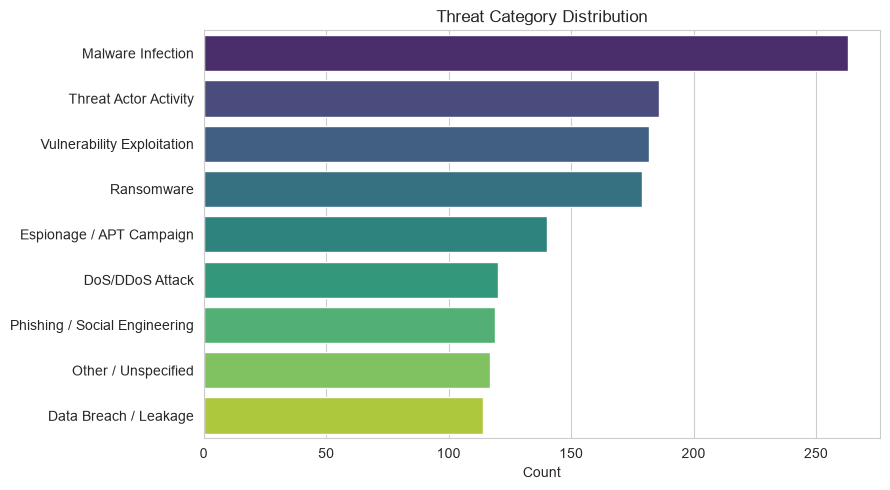

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df['threat_category'].value_counts().index
sns.countplot(data=df, y='threat_category', order=order, palette='viridis', ax=ax)
ax.set_title('Threat Category Distribution')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
savefig(fig, '01_class_distribution.png')
plt.show()


#### 5.2 Class Balance — Donut Chart

Saved: outputs\02_class_donut.png


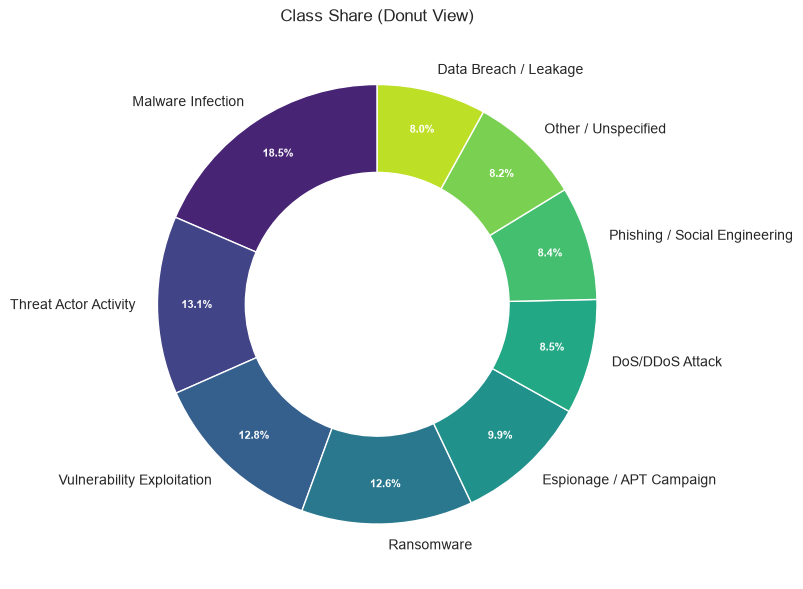

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
counts = df['threat_category'].value_counts()
colors = sns.color_palette('viridis', len(counts))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90,
    colors=colors, pctdistance=0.82,
    wedgeprops=dict(width=0.4, edgecolor='white')
)
ax.set_title('Class Share (Donut View)')
plt.setp(autotexts, size=8, color='white', weight='bold')
plt.tight_layout()
savefig(fig, '02_class_donut.png')
plt.show()


#### 5.3 Text Length Distribution & Outlier Detection

C:\Users\junaid\AppData\Local\Temp\ipykernel_12740\851622626.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='threat_category', x='word_count', ax=axes[1], palette='coolwarm')


Saved: outputs\03_text_length_outliers.png


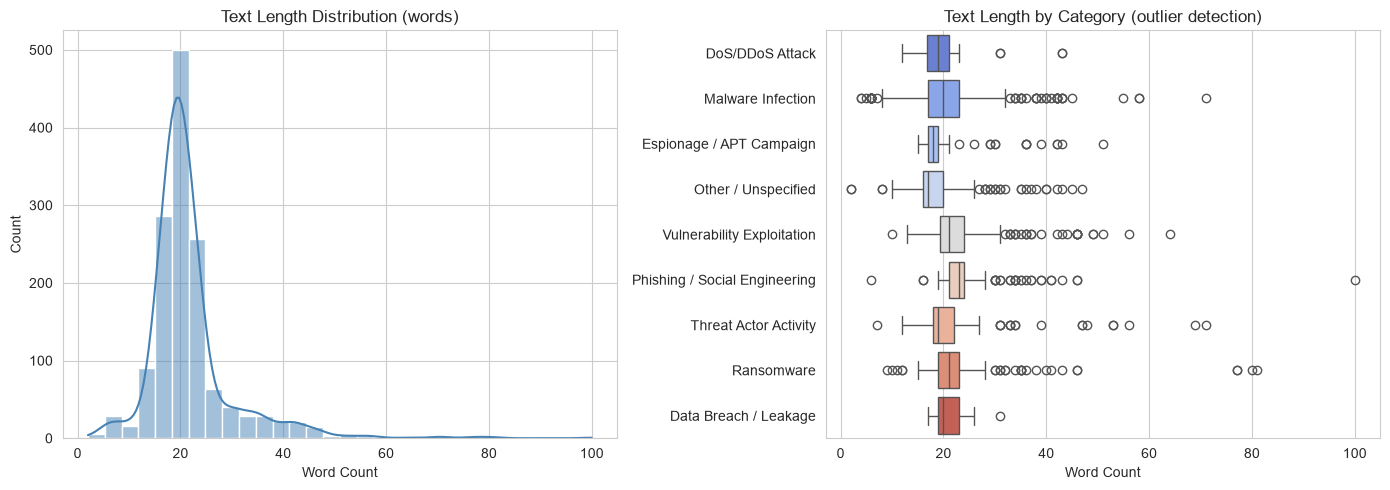

Records flagged as length outliers (IQR method): 194 / 1420


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['word_count'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Text Length Distribution (words)')
axes[0].set_xlabel('Word Count')

sns.boxplot(data=df, y='threat_category', x='word_count', ax=axes[1], palette='coolwarm')
axes[1].set_title('Text Length by Category (outlier detection)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('')

plt.tight_layout()
savefig(fig, '03_text_length_outliers.png')
plt.show()

q1, q3 = df['word_count'].quantile([0.25, 0.75])
iqr = q3 - q1
outlier_mask = (df['word_count'] < q1 - 1.5 * iqr) | (df['word_count'] > q3 + 1.5 * iqr)
print(f"Records flagged as length outliers (IQR method): {outlier_mask.sum()} / {len(df)}")


#### 5.4 Word Cloud

Saved: outputs\04_wordcloud.png


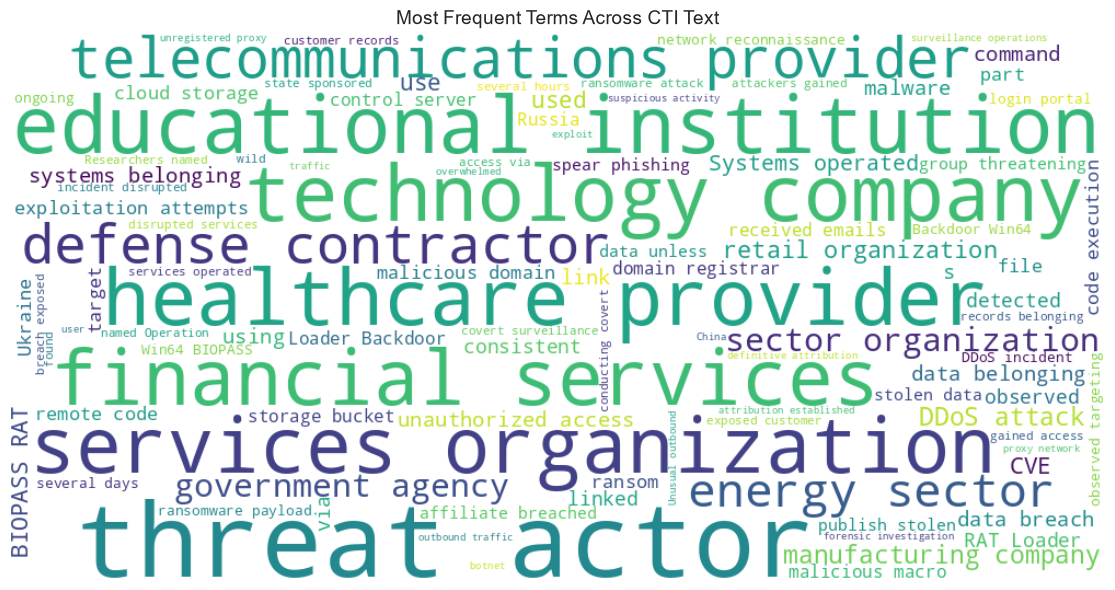

In [27]:
all_text = ' '.join(df['text'].dropna())
wc = WordCloud(width=1000, height=500, background_color='white',
                colormap='viridis', max_words=100).generate(all_text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Frequent Terms Across CTI Text', fontsize=14)
plt.tight_layout()
savefig(fig, '04_wordcloud.png')
plt.show()


#### 5.5 Entity Type Frequency

C:\Users\junaid\AppData\Local\Temp\ipykernel_12740\96964868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=all_entity_types, order=order, palette='mako', ax=ax)


Saved: outputs\05_entity_type_frequency.png


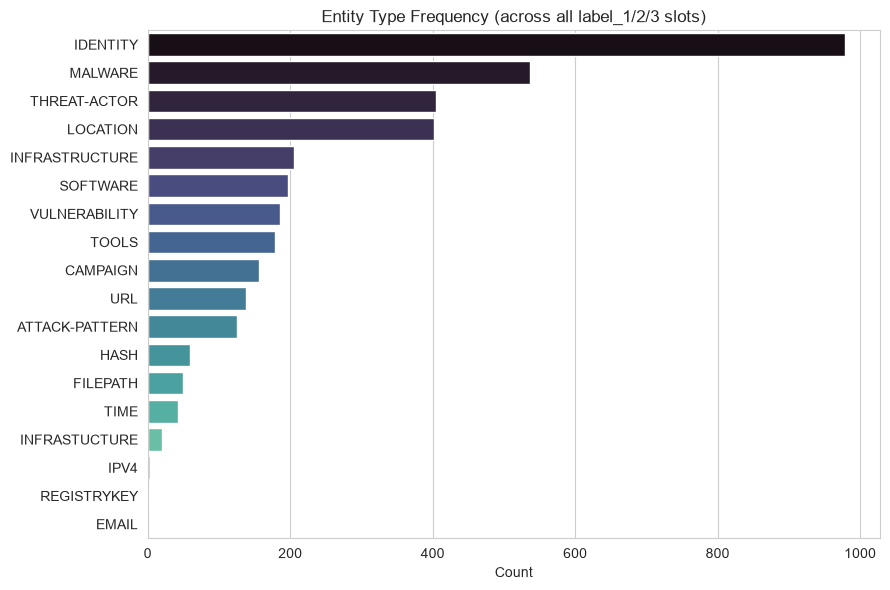

In [28]:
all_entity_types = pd.concat([df['label_1'], df['label_2'], df['label_3']])
all_entity_types = all_entity_types[all_entity_types != 'NONE'].dropna()

fig, ax = plt.subplots(figsize=(9, 6))
order = all_entity_types.value_counts().index
sns.countplot(y=all_entity_types, order=order, palette='mako', ax=ax)
ax.set_title('Entity Type Frequency (across all label_1/2/3 slots)')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
savefig(fig, '05_entity_type_frequency.png')
plt.show()


#### 5.6 Entity-Aware & Text Features by Category

C:\Users\junaid\AppData\Local\Temp\ipykernel_12740\2422504493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='threat_category', x='entity_density', ax=axes[0], palette='crest')
C:\Users\junaid\AppData\Local\Temp\ipykernel_12740\2422504493.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='threat_category', x='threat_context_score', ax=axes[1], palette='crest')
C:\Users\junaid\AppData\Local\Temp\ipykernel_12740\2422504493.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='threat_category', x='rare_en

Saved: outputs\06_eda_features_by_category.png


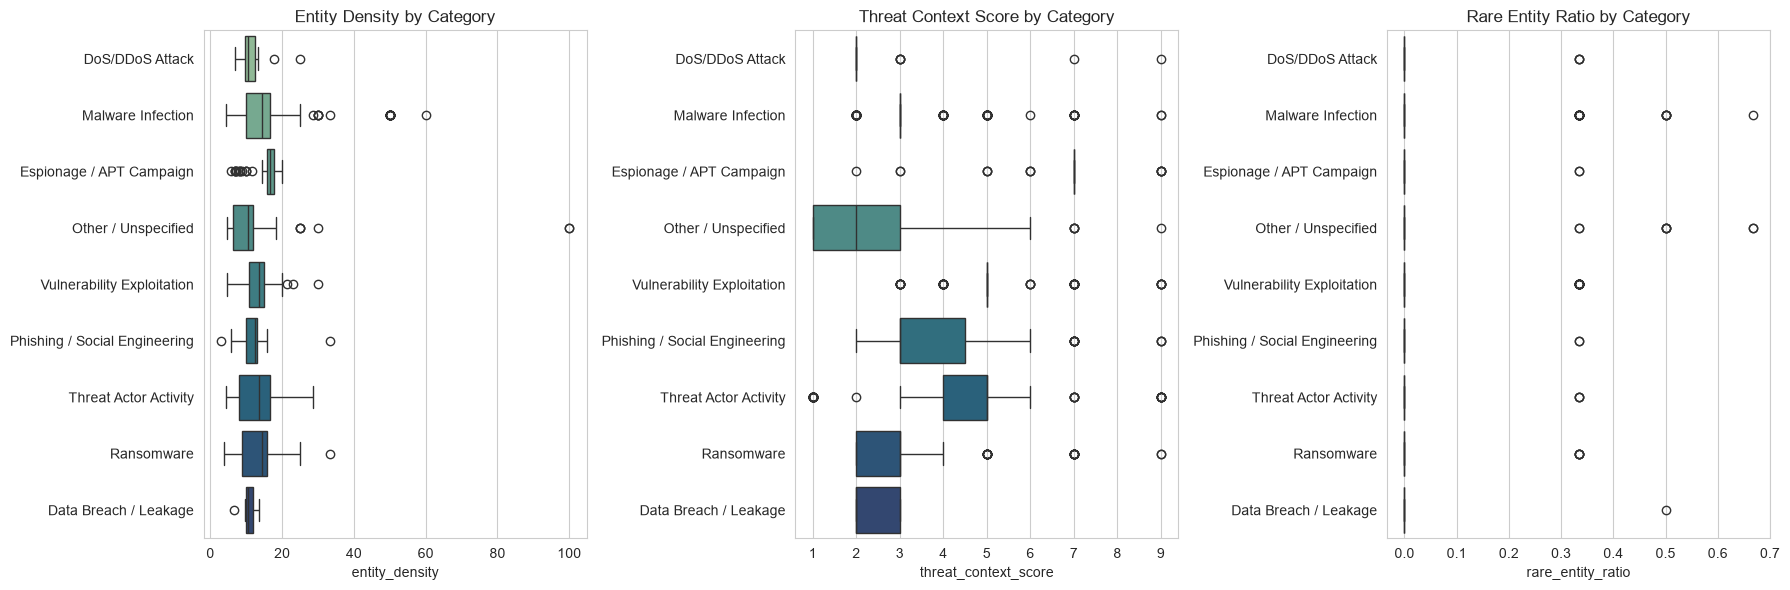

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df, y='threat_category', x='entity_density', ax=axes[0], palette='crest')
axes[0].set_title('Entity Density by Category')
axes[0].set_ylabel('')

sns.boxplot(data=df, y='threat_category', x='threat_context_score', ax=axes[1], palette='crest')
axes[1].set_title('Threat Context Score by Category')
axes[1].set_ylabel('')

sns.boxplot(data=df, y='threat_category', x='rare_entity_ratio', ax=axes[2], palette='crest')
axes[2].set_title('Rare Entity Ratio by Category')
axes[2].set_ylabel('')

plt.tight_layout()
savefig(fig, '06_eda_features_by_category.png')
plt.show()


#### 5.7 Feature Correlation Heatmap

Saved: outputs\07_feature_correlation.png


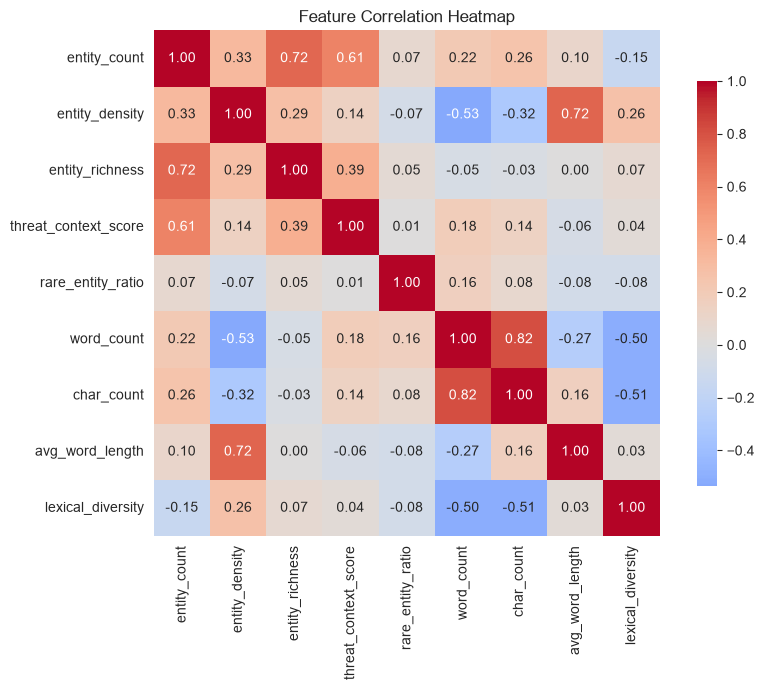

In [30]:
numeric_cols = ['entity_count', 'entity_density', 'entity_richness', 'threat_context_score',
                 'rare_entity_ratio', 'word_count', 'char_count', 'avg_word_length', 'lexical_diversity']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
savefig(fig, '07_feature_correlation.png')
plt.show()


#### 5.8 Entity Density vs Threat Context Score, by Category

Saved: outputs\08_density_vs_context_scatter.png


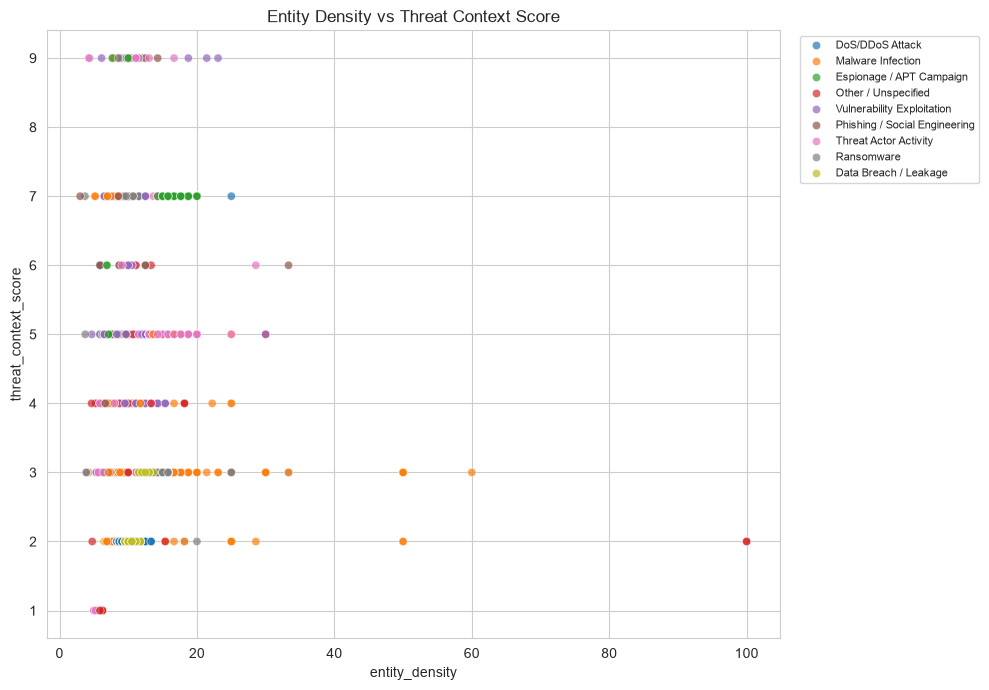

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=df, x='entity_density', y='threat_context_score', hue='threat_category',
                 palette='tab10', alpha=0.7, ax=ax)
ax.set_title('Entity Density vs Threat Context Score')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
savefig(fig, '08_density_vs_context_scatter.png')
plt.show()


#### 5.9 Per-Category Summary Table

In [32]:
summary = df.groupby('threat_category').agg(
    count=('id', 'count'),
    avg_entity_density=('entity_density', 'mean'),
    avg_entity_richness=('entity_richness', 'mean'),
    avg_threat_context_score=('threat_context_score', 'mean'),
    avg_rare_entity_ratio=('rare_entity_ratio', 'mean'),
    avg_word_count=('word_count', 'mean'),
    avg_lexical_diversity=('lexical_diversity', 'mean'),
).sort_values('count', ascending=False).round(3)
summary


,count,avg_entity_density,avg_entity_richness,avg_threat_context_score,avg_rare_entity_ratio,avg_word_count,avg_lexical_diversity
threat_category,,,,,,,
Malware Infection,263,16.805,2.437,3.376,0.032,21.175,0.927
Threat Actor Activity,186,12.592,2.371,4.392,0.005,21.737,0.943
Vulnerability Exploitation,182,13.262,2.648,5.121,0.035,23.714,0.934
Ransomware,179,12.637,2.520,3.196,0.009,23.559,0.906
Espionage / APT Campaign,140,16.114,2.814,6.914,0.005,19.486,0.968
DoS/DDoS Attack,120,11.004,2.000,2.133,0.008,19.217,0.925
Phishing / Social Engineering,119,11.599,2.580,3.647,0.006,24.983,0.914
Other / Unspecified,117,11.882,1.786,2.556,0.034,19.966,0.962
Data Breach / Leakage,114,11.007,2.263,2.263,0.004,20.474,0.921


### 6. Train/Test Split Strategy

Given class imbalance and dataset size, stratified 5-fold cross-validation is
used throughout rather than a single train-test split; every model is
evaluated on all 5 folds and results are reported as mean ± standard deviation.


In [34]:
# from google.colab import drive
# drive.mount('/content/drive')

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold

le = LabelEncoder()
y = df['threat_category']
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

print("Classes:", list(le.classes_))
print("\nClass counts:\n", y.value_counts())

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


Classes: ['Data Breach / Leakage', 'DoS/DDoS Attack', 'Espionage / APT Campaign', 'Malware Infection', 'Other / Unspecified', 'Phishing / Social Engineering', 'Ransomware', 'Threat Actor Activity', 'Vulnerability Exploitation']

Class counts:
 threat_category
Malware Infection                263
Threat Actor Activity            186
Vulnerability Exploitation       182
Ransomware                       179
Espionage / APT Campaign         140
DoS/DDoS Attack                  120
Phishing / Social Engineering    119
Other / Unspecified              117
Data Breach / Leakage            114
Name: count, dtype: int64


### 7. Baseline Models — scikit-learn

*(A pure rule-based keyword baseline is deliberately omitted: since
`threat_category` itself was constructed using keyword rules, a
keyword-matching "baseline" evaluated against those same labels would be
circular. TF-IDF + classical ML serves as the non-neural baseline instead.)*

#### 7.1 TF-IDF + Logistic Regression & SVM


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, cross_val_predict

X_text = df['text'].fillna('')
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(X_text)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
logreg_scores = cross_val_score(logreg, X_tfidf, y_enc, cv=skf, scoring='f1_macro')
print(f"TF-IDF + Logistic Regression | macro-F1: {logreg_scores.mean():.4f} +/- {logreg_scores.std():.4f}")

svm = SVC(kernel='linear', class_weight='balanced', random_state=SEED)
svm_scores = cross_val_score(svm, X_tfidf, y_enc, cv=skf, scoring='f1_macro')
print(f"TF-IDF + SVM                 | macro-F1: {svm_scores.mean():.4f} +/- {svm_scores.std():.4f}")

# Out-of-fold predictions (each record predicted from the one fold where it was
# held out) - used later for the diagnostic error analysis and confusion matrix.
logreg_oof = cross_val_predict(logreg, X_tfidf, y_enc, cv=skf)
svm_oof = cross_val_predict(svm, X_tfidf, y_enc, cv=skf)


TF-IDF + Logistic Regression | macro-F1: 0.9056 +/- 0.0159
TF-IDF + SVM                 | macro-F1: 0.9108 +/- 0.0209


#### 7.2 BiLSTM (deep learning baseline)

In [36]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score

torch.manual_seed(SEED)

all_words = set()
for t in X_text.str.lower():
    all_words.update(t.split())
vocab = {w: i + 2 for i, w in enumerate(sorted(all_words))}
vocab['<pad>'], vocab['<unk>'] = 0, 1
MAX_LEN = 60

def encode_text(t):
    ids = [vocab.get(w, 1) for w in str(t).lower().split()[:MAX_LEN]]
    return ids + [0] * (MAX_LEN - len(ids))

X_encoded = np.array([encode_text(t) for t in X_text])


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, num_classes=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))


In [37]:
def train_eval_bilstm(X_encoded, y_enc, skf, num_classes, vocab_size, epochs=15, batch_size=16):
    fold_f1s = []
    oof_preds = np.zeros(len(y_enc), dtype=int)
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_encoded, y_enc)):
        torch.manual_seed(SEED)
        model = BiLSTMClassifier(vocab_size, num_classes=num_classes)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
        criterion = nn.CrossEntropyLoss()

        X_tr = torch.tensor(X_encoded[tr_idx], dtype=torch.long)
        y_tr = torch.tensor(y_enc[tr_idx], dtype=torch.long)
        X_te = torch.tensor(X_encoded[te_idx], dtype=torch.long)
        y_te_np = y_enc[te_idx]

        model.train()
        for epoch in range(epochs):
            perm = torch.randperm(len(X_tr))
            for i in range(0, len(X_tr), batch_size):
                idx = perm[i:i + batch_size]
                optimizer.zero_grad()
                loss = criterion(model(X_tr[idx]), y_tr[idx])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_te).argmax(dim=1).numpy()
        oof_preds[te_idx] = preds
        f1 = f1_score(y_te_np, preds, average='macro', zero_division=0)
        fold_f1s.append(f1)
        print(f"  Fold {fold + 1} macro-F1: {f1:.4f}")
    return np.array(fold_f1s), oof_preds

bilstm_scores, bilstm_oof = train_eval_bilstm(X_encoded, y_enc, skf, num_classes, len(vocab))
print(f"\nBiLSTM | macro-F1: {bilstm_scores.mean():.4f} +/- {bilstm_scores.std():.4f}")


  Fold 1 macro-F1: 0.8619
  Fold 2 macro-F1: 0.8580


KeyboardInterrupt: 

### 7.3 Diagnostic Error Analysis (Baseline Stage)

Does the strongest baseline so far struggle more on records the EDA flagged
as structurally unusual — high Rare Entity Ratio, or a particular Threat
Context Score band? This is repeated again at the end of the notebook using
the best-performing model overall, once all models have been trained.


In [ ]:
best_baseline_name = max(
    [('TF-IDF + LogReg', logreg_scores.mean(), logreg_oof),
     ('TF-IDF + SVM', svm_scores.mean(), svm_oof),
     ('BiLSTM', bilstm_scores.mean(), bilstm_oof)],
    key=lambda x: x[1]
)
print(f"Strongest baseline so far: {best_baseline_name[0]} (macro-F1 {best_baseline_name[1]:.4f})")




Strongest baseline so far: TF-IDF + SVM (macro-F1 0.9108)


## 8. Proposed Hybrid Model — SecureBERT-BiLSTM-Attention



Only the proposed configuration is trained here (SecureBERT encoder ->
BiLSTM -> attention -> classification head). Its result is compared against
the literature benchmark reported by Hidayatulloh et al. (2026) for the
equivalent general-BERT hybrid (macro-F1 0.86), rather than against a
separately-run general-BERT hybrid on this dataset.

In [ ]:
# !pip install -q transformers
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    # Enable cuDNN auto-tuner for faster computation
    torch.backends.cudnn.benchmark = True

SECUREBERT_CHECKPOINT = "ehsanaghaei/SecureBERT"
securebert_tokenizer = AutoTokenizer.from_pretrained(SECUREBERT_CHECKPOINT)

MAX_LEN_TRANSFORMER = 64

def tokenize_texts(texts, tokenizer, max_len=MAX_LEN_TRANSFORMER):
    enc = tokenizer(list(texts), padding='max_length', truncation=True,
                     max_length=max_len, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask']

secbert_ids, secbert_mask = tokenize_texts(X_text, securebert_tokenizer)
if torch.cuda.is_available():
    secbert_ids = secbert_ids.pin_memory()
    secbert_mask = secbert_mask.pin_memory()


c:\Users\junaid\miniconda3\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory: 4.29 GB


c:\Users\junaid\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


#### 8.1 Hybrid Architecture

In [ ]:
class HybridClassifier(nn.Module):

    def __init__(self, encoder, hidden_size, lstm_hidden, num_classes, freeze_layers=8):
        super().__init__()
        self.encoder = encoder
        for i, layer in enumerate(self.encoder.encoder.layer):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        self.lstm = nn.LSTM(hidden_size, lstm_hidden, batch_first=True, bidirectional=True)
        self.attn_fc = nn.Linear(lstm_hidden * 2, 1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        encoder_out = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        lstm_out, _ = self.lstm(encoder_out)

        attn_scores = self.attn_fc(lstm_out).squeeze(-1)
        attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)
        context = (lstm_out * attn_weights).sum(dim=1)

        return self.fc(self.dropout(context))


#### 8.2 Training Loop

In [ ]:
def train_eval_transformer(model_fn, input_ids, attention_mask, y_enc, skf,
                            epochs=5, batch_size=8, lr=2e-5):

    fold_f1s = []
    oof_preds = np.zeros(len(y_enc), dtype=int)

    for fold, (tr_idx, te_idx) in enumerate(skf.split(input_ids, y_enc)):
        torch.manual_seed(SEED)
        model = model_fn().to(device)
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        criterion = nn.CrossEntropyLoss()

        ids_tr, mask_tr = input_ids[tr_idx].to(device), attention_mask[tr_idx].to(device)
        y_tr = torch.tensor(y_enc[tr_idx], dtype=torch.long).to(device)
        ids_te, mask_te = input_ids[te_idx].to(device), attention_mask[te_idx].to(device)

        model.train()
        for epoch in range(epochs):
            perm = torch.randperm(len(ids_tr))
            for i in range(0, len(ids_tr), batch_size):
                idx = perm[i:i + batch_size]
                optimizer.zero_grad()
                loss = criterion(model(ids_tr[idx], mask_tr[idx]), y_tr[idx])
                loss.backward()
                optimizer.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for i in range(0, len(ids_te), batch_size):
                batch_preds = model(ids_te[i:i+batch_size], mask_te[i:i+batch_size]).argmax(dim=1)
                preds.append(batch_preds.cpu().numpy())
        preds = np.concatenate(preds)
        oof_preds[te_idx] = preds
        f1 = f1_score(y_enc[te_idx], preds, average='macro', zero_division=0)
        fold_f1s.append(f1)
        print(f"  Fold {fold + 1} macro-F1: {f1:.4f}")

        del model
        torch.cuda.empty_cache()

    return np.array(fold_f1s), oof_preds


#### 8.3 Train & Evaluate

In [ ]:
# !pip install --upgrade torch torchvision torchaudio transformers scikit-learn pandas numpy matplotlib seaborn wordcloud streamlit pyngrok

In [ ]:
def make_hybrid_securebert():
    # Use trust_remote_code=True to bypass torch version check
    encoder = AutoModel.from_pretrained(SECUREBERT_CHECKPOINT, trust_remote_code=True)
    return HybridClassifier(encoder, hidden_size=768, lstm_hidden=128, num_classes=num_classes)

hybrid_secbert_scores, hybrid_secbert_oof = train_eval_transformer(make_hybrid_securebert, secbert_ids, secbert_mask, y_enc, skf)
print(f"\nHybrid SecureBERT-BiLSTM-Attention (proposed) | macro-F1: {hybrid_secbert_scores.mean():.4f} +/- {hybrid_secbert_scores.std():.4f}")
print(f"Literature benchmark (Hidayatulloh et al., 2026, general-BERT hybrid): 0.86")


c:\Users\junaid\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\junaid\miniconda3\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


c:\Users\junaid\miniconda3\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\junaid\miniconda3\Lib\site-packages\transformers\modeling_utils.py:484: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`

  Fold 1 macro-F1: 0.9266


c:\Users\junaid\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\junaid\miniconda3\Lib\site-packages\transformers\modeling_utils.py:484: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch

  Fold 2 macro-F1: 0.9455


...

  Fold 3 macro-F1: 0.9330


c:\Users\junaid\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\junaid\miniconda3\Lib\site-packages\transformers\modeling_utils.py:484: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch

  Fold 4 macro-F1: 0.9389


c:\Users\junaid\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\junaid\miniconda3\Lib\site-packages\transformers\modeling_utils.py:484: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch

  Fold 5 macro-F1: 0.9285

Hybrid SecureBERT-BiLSTM-Attention (proposed) | macro-F1: 0.9345 +/- 0.0070
Literature benchmark (Hidayatulloh et al., 2026, general-BERT hybrid): 0.86


## 9. Model Comparison & Best Model Selection

Four models, same data, same stratified 5-fold protocol.


In [ ]:
all_results = {
    "TF-IDF + LogReg": (logreg_scores.mean(), logreg_scores.std(), logreg_oof),
    "TF-IDF + SVM": (svm_scores.mean(), svm_scores.std(), svm_oof),
    "BiLSTM (from scratch)": (bilstm_scores.mean(), bilstm_scores.std(), bilstm_oof),
    "Hybrid SecureBERT-BiLSTM-Attention (proposed)": (hybrid_secbert_scores.mean(), hybrid_secbert_scores.std(), hybrid_secbert_oof),
}

results_df = pd.DataFrame(
    {name: (mean, std) for name, (mean, std, _) in all_results.items()},
    index=["macro_F1_mean", "macro_F1_std"]
).T.sort_values("macro_F1_mean", ascending=False).round(4)

print(results_df)

best_model_name = results_df.index[0]
best_model_oof = all_results[best_model_name][2]
print(f"\nBest model: {best_model_name} (macro-F1 {results_df.iloc[0]['macro_F1_mean']:.4f})")


                                               macro_F1_mean  macro_F1_std
Hybrid SecureBERT-BiLSTM-Attention (proposed)         0.9345        0.0070
TF-IDF + SVM                                          0.9108        0.0209
TF-IDF + LogReg                                       0.9056        0.0159
BiLSTM (from scratch)                                 0.8661        0.0091

Best model: Hybrid SecureBERT-BiLSTM-Attention (proposed) (macro-F1 0.9345)


Saved: outputs\09_full_model_comparison.png


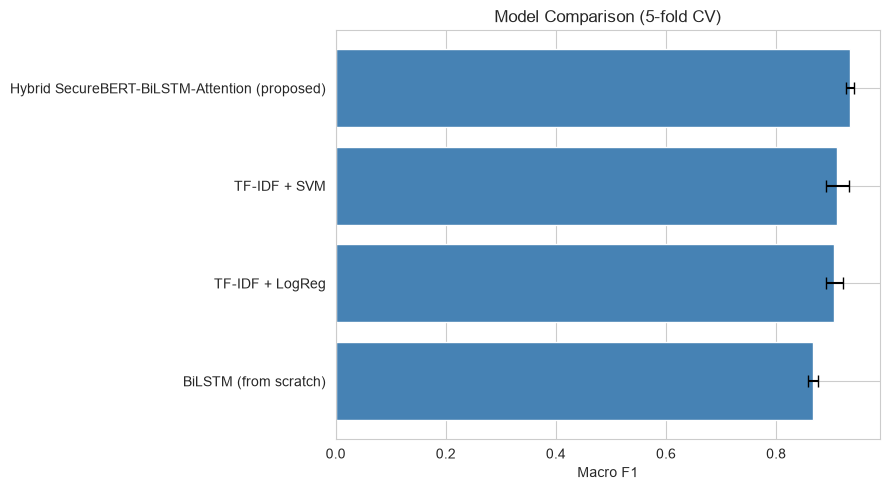

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(results_df.index, results_df['macro_F1_mean'],
        xerr=results_df['macro_F1_std'], capsize=4, color='steelblue')
ax.set_xlabel('Macro F1')
ax.set_title('Model Comparison (5-fold CV)')
ax.invert_yaxis()
plt.tight_layout()
savefig(fig, '09_full_model_comparison.png')
plt.show()


#### 9.1 Confusion Matrix — Best Model

                               precision    recall  f1-score   support

        Data Breach / Leakage       0.99      0.99      0.99       114
              DoS/DDoS Attack       0.99      0.97      0.98       120
     Espionage / APT Campaign       0.99      0.97      0.98       140
            Malware Infection       0.89      0.95      0.92       263
          Other / Unspecified       0.84      0.86      0.85       117
Phishing / Social Engineering       0.90      0.94      0.92       119
                   Ransomware       0.98      0.89      0.93       179
        Threat Actor Activity       0.92      0.88      0.90       186
   Vulnerability Exploitation       0.95      0.95      0.95       182

                     accuracy                           0.93      1420
                    macro avg       0.94      0.93      0.93      1420
                 weighted avg       0.93      0.93      0.93      1420

Saved: outputs\10_best_model_confusion_matrix.png


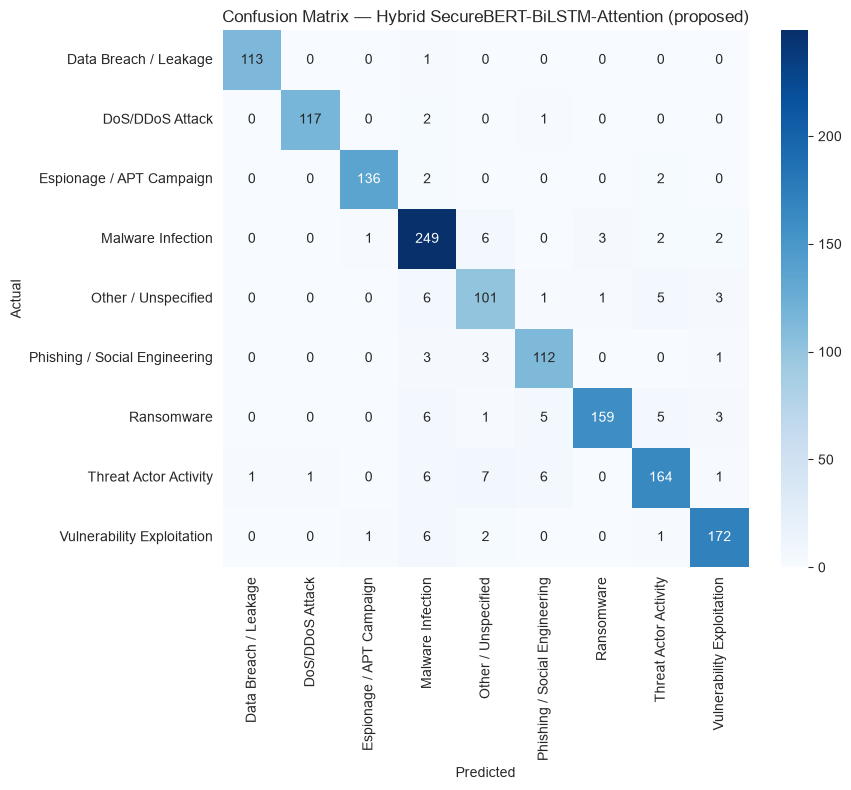

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_enc, best_model_oof, target_names=le.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 8))
cm = confusion_matrix(y_enc, best_model_oof)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_title(f'Confusion Matrix — {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=90)
plt.tight_layout()
savefig(fig, '10_best_model_confusion_matrix.png')
plt.show()


## 10. Full Metrics Report — All Models

Accuracy, macro-precision, macro-recall, macro-F1, and macro-ROC-AUC for
every model in `all_results` (built in Section 9). ROC-AUC for a 9-class
problem is computed one-vs-rest and averaged (`roc_auc_score` with
`multi_class='ovr'`), which needs predicted probabilities, not just hard
labels — handled per model type below.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_enc, classes=list(range(num_classes)))

def safe_roc_auc(y_true_bin, proba):
    try:
        return roc_auc_score(y_true_bin, proba, average='macro', multi_class='ovr')
    except ValueError:
        return None

def full_metrics_report(name, y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {
        "Model": name, "Accuracy": acc, "Precision (macro)": prec,
        "Recall (macro)": rec, "F1 (macro)": f1,
    }
report_rows = []
for name, (mean_f1, std_f1, oof_preds) in all_results.items():
    report_rows.append(full_metrics_report(name, y_enc, oof_preds, proba=None))

metrics_df = pd.DataFrame(report_rows).set_index("Model").round(4)
metrics_df


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Model,,,,
TF-IDF + LogReg,0.8944,0.9235,0.8939,0.9059
TF-IDF + SVM,0.9014,0.9261,0.9004,0.9113
BiLSTM (from scratch),0.8549,0.8718,0.8628,0.8667
Hybrid SecureBERT-BiLSTM-Attention (proposed),0.9317,0.9365,0.9338,0.9347


#### 10.1 Visual Comparison Across All Models

Heatmap and grouped bars make it easy to compare model performance across all reported metrics in one view.

Saved: outputs\11_all_model_metrics_heatmap.png


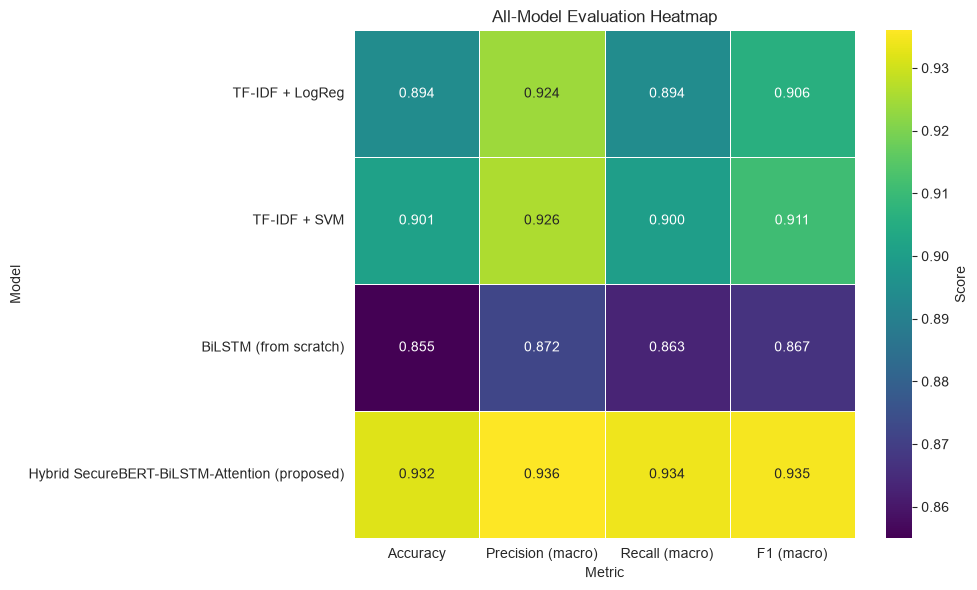

Saved: outputs\12_all_model_metrics_grouped_bar.png


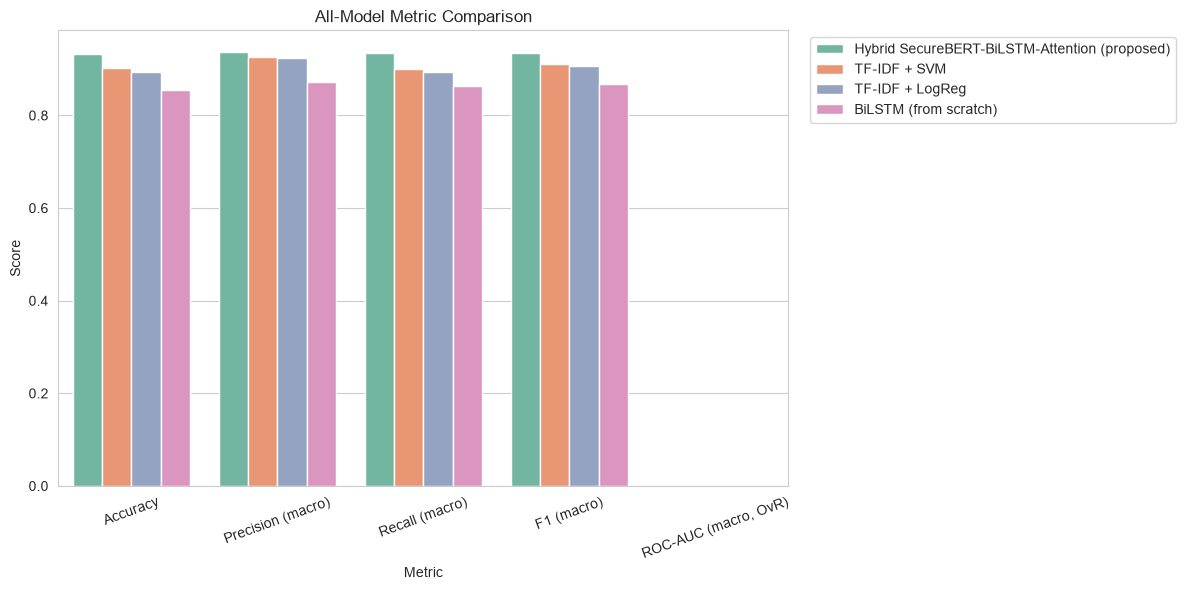

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Model,,,,
Hybrid SecureBERT-BiLSTM-Attention (proposed),0.9317,0.9365,0.9338,0.9347
TF-IDF + SVM,0.9014,0.9261,0.9004,0.9113
TF-IDF + LogReg,0.8944,0.9235,0.8939,0.9059
BiLSTM (from scratch),0.8549,0.8718,0.8628,0.8667


In [ ]:
metrics_table = metrics_df.reset_index().rename(columns={'index': 'Model'})
metrics_for_plot = metrics_table.set_index('Model')

# Long-form data for grouped bar plots
metrics_long = metrics_for_plot.reset_index().melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)

# Sort models by F1 descending for readability
metrics_long['Model'] = pd.Categorical(
    metrics_long['Model'],
    categories=metrics_for_plot.sort_values('F1 (macro)', ascending=False).index,
    ordered=True,
)

# Heatmap of metric values
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    metrics_for_plot.round(3),
    annot=True, fmt='.3f', cmap='viridis', linewidths=0.5, cbar_kws={'label': 'Score'}, ax=ax
)
ax.set_title('All-Model Evaluation Heatmap')
ax.set_xlabel('Metric')
ax.set_ylabel('Model')
plt.tight_layout()
savefig(fig, '11_all_model_metrics_heatmap.png')
plt.show()

# Grouped bar chart for all metrics
fig, ax = plt.subplots(figsize=(12, 6))
order = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'ROC-AUC (macro, OvR)']
filtered = metrics_long[metrics_long['Metric'].isin(order)]
filtered['Metric'] = pd.Categorical(filtered['Metric'], categories=order, ordered=True)

sns.barplot(
    data=filtered, x='Metric', y='Score', hue='Model', palette='Set2', ax=ax
)
ax.set_title('All-Model Metric Comparison')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
savefig(fig, '12_all_model_metrics_grouped_bar.png')
plt.show()

# Summary table of ranked models by F1
metrics_for_plot[['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']].sort_values(
    'F1 (macro)', ascending=False
)


## 11. Best Model — Detailed Metric Visualizations


#### 11.1 Per-Class Precision / Recall / F1

Saved: outputs\13_best_model_per_class_metrics.png


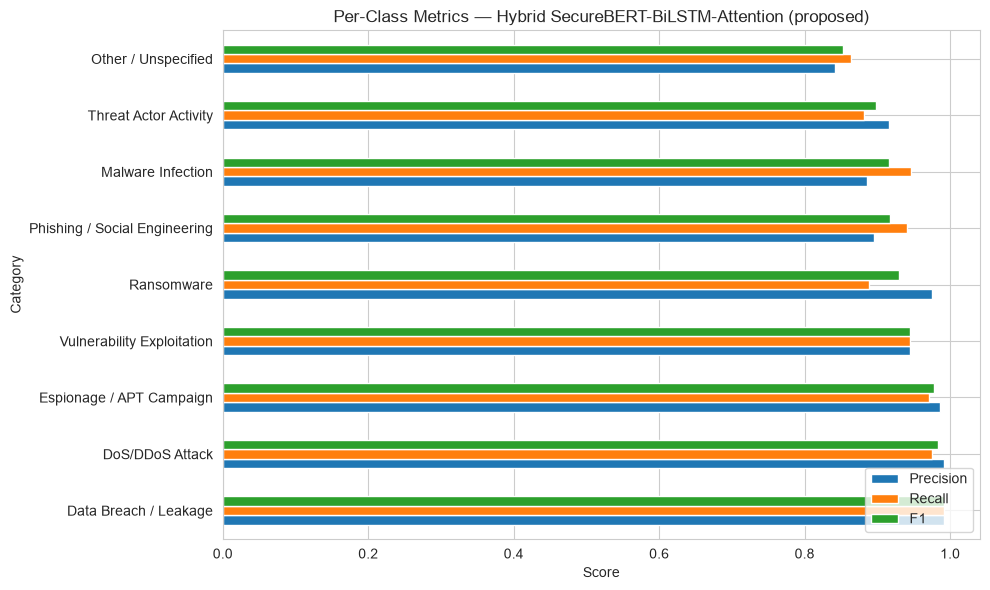

,Category,Precision,Recall,F1,Support
0,Data Breach / Leakage,0.991228,0.991228,0.991228,114
1,DoS/DDoS Attack,0.991525,0.975000,0.983193,120
2,Espionage / APT Campaign,0.985507,0.971429,0.978417,140
8,Vulnerability Exploitation,0.945055,0.945055,0.945055,182
6,Ransomware,0.975460,0.888268,0.929825,179
5,Phishing / Social Engineering,0.896000,0.941176,0.918033,119
3,Malware Infection,0.886121,0.946768,0.915441,263
7,Threat Actor Activity,0.916201,0.881720,0.898630,186
4,Other / Unspecified,0.841667,0.863248,0.852321,117


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_per_class, support = precision_recall_fscore_support(
    y_enc, best_model_oof, zero_division=0
)

per_class_df = pd.DataFrame({
    'Category': le.classes_, 'Precision': precision, 'Recall': recall,
    'F1': f1_per_class, 'Support': support,
}).sort_values('F1', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
per_class_df.set_index('Category')[['Precision', 'Recall', 'F1']].plot(kind='barh', ax=ax)
ax.set_title(f'Per-Class Metrics — {best_model_name}')
ax.set_xlabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
savefig(fig, '13_best_model_per_class_metrics.png')
plt.show()

per_class_df


#### 11.2 Per-Class Accuracy Heatmap (Normalized Confusion Matrix)

Saved: outputs\14_best_model_normalized_confusion.png


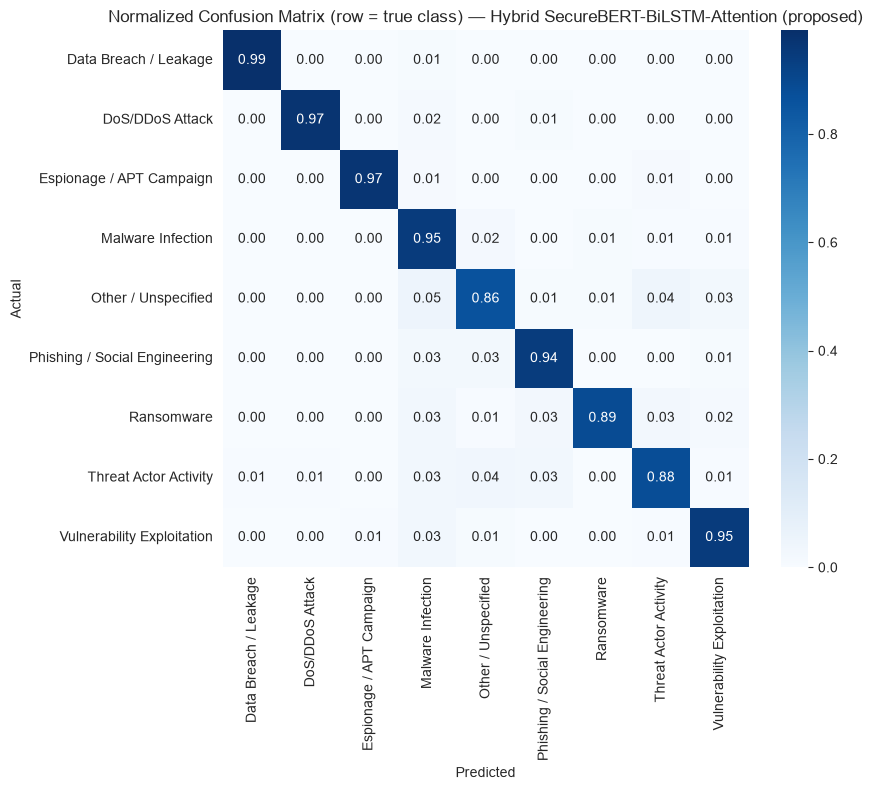

In [ ]:
cm = confusion_matrix(y_enc, best_model_oof, normalize='true')

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_title(f'Normalized Confusion Matrix (row = true class) — {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=90)
plt.tight_layout()
savefig(fig, '14_best_model_normalized_confusion.png')
plt.show()


## streamlit dashboard implementation

In [ ]:
import joblib
import torch
from transformers import AutoModel, AutoTokenizer

# 1. Save LabelEncoder
joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.joblib'))

# 2. Save Tokenizer
securebert_tokenizer.save_pretrained(os.path.join(MODELS_DIR, 'securebert_tokenizer'))

# 3. Train on full dataset (or a single high-perf fold) and save weights
# For deployment, we often train on the full dataset available
def save_best_model():
    model = make_hybrid_securebert().to(device)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    criterion = torch.nn.CrossEntropyLoss()

    # Use full data for the final deployment model
    ids = secbert_ids.to(device)
    mask = secbert_mask.to(device)
    labels = torch.tensor(y_enc, dtype=torch.long).to(device)

    model.train()
    for epoch in range(3): # Sufficient for final weights capture
        perm = torch.randperm(len(ids))
        for i in range(0, len(ids), 8):
            idx = perm[i:i + 8]
            optimizer.zero_grad()
            outputs = model(ids[idx], mask[idx])
            loss = criterion(outputs, labels[idx])
            loss.backward()
            optimizer.step()

    model_path = os.path.join(MODELS_DIR, 'hybrid_secbert_model.pth')
    torch.save(model.state_dict(), model_path)
    print(f"Model artifacts exported successfully to {MODELS_DIR}")

save_best_model()

c:\Users\junaid\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\junaid\miniconda3\Lib\site-packages\transformers\modeling_utils.py:484: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch

Model artifacts exported successfully to models_outputs


## 12. Interactive Streamlit Dashboard Deployment

This section handles the creation of the `app.py` file and the setup of the public tunnel using `ngrok`.

In [ ]:
!pip install -q streamlit pyngrok

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import joblib
import os
from transformers import AutoTokenizer, AutoModel

# --- Model Architecture 
class HybridClassifier(nn.Module):
    def __init__(self, encoder, hidden_size, lstm_hidden, num_classes):
        super().__init__()
        self.encoder = encoder
        self.lstm = nn.LSTM(hidden_size, lstm_hidden, batch_first=True, bidirectional=True)
        self.attn_fc = nn.Linear(lstm_hidden * 2, 1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        encoder_out = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        lstm_out, _ = self.lstm(encoder_out)
        attn_scores = self.attn_fc(lstm_out).squeeze(-1)
        attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)
        context = (lstm_out * attn_weights).sum(dim=1)
        return self.fc(self.dropout(context))


st.set_page_config(page_title="Cybersecurity Threat Classifier", layout="wide")

# --- Session State for Authentication ---
if 'logged_in' not in st.session_state:
    st.session_state.logged_in = False
if 'username' not in st.session_state:
    st.session_state.username = None

# --- Constants & Loading ---
MODELS_DIR = "models_outputs"
SECUREBERT_CHECKPOINT = "ehsanaghaei/SecureBERT"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Reject low-confidence predictions
CONFIDENCE_THRESHOLD = 0.70

@st.cache_resource
def load_artifacts():
    # Load LabelEncoder
    le = joblib.load(os.path.join(MODELS_DIR, 'label_encoder.joblib'))
    # Load Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(os.path.join(MODELS_DIR, 'securebert_tokenizer'))
    # Load Model
    base_encoder = AutoModel.from_pretrained(SECUREBERT_CHECKPOINT)
    model = HybridClassifier(base_encoder, hidden_size=768, lstm_hidden=128, num_classes=len(le.classes_))
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'hybrid_secbert_model.pth'), map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return le, tokenizer, model

# --- Login / Signup Page ---
def login_page():
    st.title("🔐 Cybersecurity Threat Classifier")
    
    col1, col2, col3 = st.columns([1, 2, 1])
    
    with col2:
        st.markdown("### Welcome")
        
        # Tabs for Login and Signup
        tab1, tab2 = st.tabs(["Login", "Sign Up"])
        
        with tab1:
            st.subheader("Login")
            login_username = st.text_input("Username", key="login_user")
            login_password = st.text_input("Password", type="password", key="login_pass")
            
            if st.button("Login", key="login_btn"):
                if login_username and login_password:
                    st.session_state.logged_in = True
                    st.session_state.username = login_username
                    st.success(f"Welcome back, {login_username}! 🎉")
                    st.rerun()
                else:
                    st.error("Please enter both username and password")
        
        with tab2:
            st.subheader("Create Account")
            signup_username = st.text_input("Choose Username", key="signup_user")
            signup_password = st.text_input("Choose Password", type="password", key="signup_pass")
            signup_password_confirm = st.text_input("Confirm Password", type="password", key="signup_pass_confirm")
            
            if st.button("Sign Up", key="signup_btn"):
                if signup_username and signup_password:
                    if signup_password == signup_password_confirm:
                        st.session_state.logged_in = True
                        st.session_state.username = signup_username
                        st.success(f"Account created successfully, {signup_username}! Welcome aboard! 🎉")
                        st.rerun()
                    else:
                        st.error("Passwords do not match")
                else:
                    st.error("Please fill in all fields")

# --- Threat Classification Page ---
def classifier_page():
    st.title("🛡️ Hybrid SecureBERT Threat Classifier")
    st.markdown(f"Welcome, **{st.session_state.username}**! Input cybersecurity-related text to classify it into threat categories.")
    
    # Logout button in sidebar
    with st.sidebar:
        if st.button("Logout"):
            st.session_state.logged_in = False
            st.session_state.username = None
            st.rerun()
    
    le, tokenizer, model = load_artifacts()
    
    # --- UI Layout ---
    input_text = st.text_area("Enter Cyber Threat Intelligence (CTI) text:", height=150,
                              placeholder="e.g., A cybersquatting domain is launching DoS attacks...")

    if st.button("Classify Threat"):
        if input_text.strip():
            with st.spinner("Analyzing..."):

                inputs = tokenizer(
                    input_text,
                    padding='max_length',
                    truncation=True,
                    max_length=64,
                    return_tensors='pt'
                ).to(DEVICE)

                with torch.no_grad():
                    outputs = model(inputs['input_ids'], inputs['attention_mask'])
                    probs = torch.softmax(outputs, dim=1)

                    confidence, pred_idx = torch.max(probs, dim=1)

                confidence = confidence.item()
                pred_idx = pred_idx.item()

                # Confidence-based rejection
                if confidence < CONFIDENCE_THRESHOLD:
                    st.warning("⚪ Not a Cyber Threat")
                    st.write(f"Confidence Score: {confidence:.2%}")

                else:
                    label = le.inverse_transform([pred_idx])[0]

                    st.subheader(f"Prediction: **{label}**")
                    st.progress(confidence)
                    st.write(f"Confidence Score: {confidence:.2%}")

    else:
        st.warning("Please enter some text to classify.")

# --- Main App Logic ---
if st.session_state.logged_in:
    classifier_page()
else:
    login_page()


Overwriting app.py


### 12.1 Launch Dashboard with Ngrok


In [ ]:
from pyngrok import ngrok
import getpass
import os
import subprocess

# Terminate existing tunnels to avoid port conflicts
ngrok.kill()

# Input authtoken securely
print("Please provide your ngrok authtoken to create the public tunnel.")
authtoken = "3IQeb8in6BNZLoUpoPniHu7a09p_6SxKFsK2QpT9DzuANNY2g"
ngrok.set_auth_token(authtoken)

# Start Streamlit in the background
# The port defaults to 8501
print("Starting Streamlit server...")
process = subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])

# Open the tunnel
public_url = ngrok.connect(8501)
print(f"\n\n[!] SUCCESS: Your dashboard is live at: {public_url}")

Please provide your ngrok authtoken to create the public tunnel.
Starting Streamlit server...


[!] SUCCESS: Your dashboard is live at: NgrokTunnel: "https://trouble-spout-reheat.ngrok-free.dev" -> "http://localhost:8501"
